# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Maria Ulva Ramadhani]
- **Email:** [mariaulvaramadhani@gmail.com]
- **ID Dicoding:** [maria_ulva_ramadhani]

## Menentukan Pertanyaan Bisnis

- Pada hari apa dan jam berapa jumlah penyewaan sepeda terbanyak?
- Bagaimana pengaruh musim dan cuaca terhadap jumlah penyewaan sepeda?
- Bagaimana perbandingan penyewaan sepeda pada hari kerja dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Input data hour

In [199]:
hour_df = pd.read_csv("hour.csv", delimiter=",")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Input data day

In [200]:
day_df = pd.read_csv("day.csv", delimiter=",")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dari dua data di atas terdapat variabel yang berbeda yaitu 'hour' yang tidak ada pada data day

### Assessing Data

**Assesing Hour**

Cek null dan data type dari data hour

In [201]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Terdapat kesalahan tipe data pada dteday 

Cek missing value dari data hour

In [202]:
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Cek duplikat pada data hour

In [203]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


Cek data deskriptif untuk melihat inaccurate value

In [204]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Assesing Day**

Cek null dan data type dari data day

In [205]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Terdapat kesalahan tipe data pada dteday

Cek missing value pada data day

In [206]:
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Cek duplikat pada data day

In [207]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


Cek data statistik untuk melihat inaccurate value

In [208]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Pada data hour terdapat kesalahan tipe data untuk dteday, tidak ada missing value, tidak ada duplikat data, dan tidak ada inaccurate value
- Pada data day terdapat kesalahan tipe data untuk dteday, tidak ada missing value, tidak ada duplikat data, dan tidak ada inaccurate value

### Cleaning Data

Mengganti tipe data dteday pada data Hour

In [209]:
datetime_columns = ["dteday"]
 
for column in datetime_columns:
  hour_df[column] = pd.to_datetime(hour_df[column])

Cek tipe data dteday yang baru

In [210]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

Mengganti tipe data pada dteday pada Data Day

In [211]:
datetime_columns = ["dteday"]
 
for column in datetime_columns:
  day_df[column] = pd.to_datetime(day_df[column])

Cek tipe data dteday yang baru

In [212]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Tipe data dteday sudah diubah menjadi datetime

## Exploratory Data Analysis (EDA)

### Explore ...

Lihat data statistik dari data Hour

In [213]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


Lihat data statistik pada data Day

In [214]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


Berdasarkan data di atas diketahui, periode diambilnya data 01-01-2011 hingga 31-12-2012. Pada data tersebut dibagi menjadi empat musim:
- 1 untuk springer
- 2 untuk summer
- 3 untuk fall
- 4 untuk winter

Terdapat empat kondisi cuaca, yaitu:
- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

Untuk Hari:
- 0 : Minggu
- 1 : Senin
- 2 : Selasa
- 3 : Rabu
- 4 : Kamis
- 5 : Jumat
- 6 : Sabtu

Mengelompokkan Hari untuk melihat total penyewa berdasarkan hari 

In [215]:
df_hari = day_df.groupby('weekday')['cnt'].sum().reset_index()

Mengurutkan berdasrkan yang terbanyak

In [216]:
df_hari_sorted = df_hari.sort_values(by='cnt', ascending=False)
print(df_hari_sorted)

   weekday     cnt
5        5  487790
4        4  485395
6        6  477807
3        3  473048
2        2  469109
1        1  455503
0        0  444027


Terlihat bahwa penyewa sepeda terbanyak ialah pada hari jumat

Mengelompokkan Hour untuk melihat jumlah penyewa pada jam tertentu

In [217]:
df_jam = hour_df.groupby('hr')['cnt'].sum().reset_index()

Mengurutkan berdasrkan yang terbanyak

In [218]:
df_jam_sorted = df_jam.sort_values(by='cnt', ascending=False)
print(df_jam_sorted)

    hr     cnt
17  17  336860
18  18  309772
8    8  261001
16  16  227748
19  19  226789
13  13  184919
12  12  184414
15  15  183149
14  14  175652
20  20  164550
9    9  159438
7    7  154171
11  11  151320
10  10  126257
21  21  125445
22  22   95612
23  23   63941
6    6   55132
0    0   39130
1    1   24164
2    2   16352
5    5   14261
3    3    8174
4    4    4428


Terlihat bahwa penyewa sepeda terbanyak ialah pada jam 17.00

Mencari Penyewa Rata-rata dan terbanyak berdasrkan hari dan jam

In [219]:
df_grouped = hour_df.groupby(['weekday', 'hr'])['cnt'].mean().reset_index()

Urutkan dari yang terbanyak

In [220]:
df_sorted = df_grouped.sort_values(by='cnt', ascending=False)
print(df_sorted)

     weekday  hr         cnt
65         2  17  544.278846
113        4  17  527.346154
66         2  18  517.567308
89         3  17  513.144231
41         1  17  502.394231
..       ...  ..         ...
27         1   3    5.113402
99         4   3    5.071429
76         3   4    4.968750
75         3   3    4.888889
51         2   3    4.152174

[168 rows x 3 columns]


Menghitung jumlah penyewa terbanyak berdasarkan hari dan jam 

In [221]:
max_users = df_grouped[df_grouped['cnt'] == df_grouped['cnt'].max()]

In [222]:
print("Penyewa terbanyak berdasarkan hari dan jam:")
print(max_users)

Penyewa terbanyak berdasarkan hari dan jam:
    weekday  hr         cnt
65        2  17  544.278846


Diketahui penyewa sepeda terbanyak pada Hari Selasa ke Jam 17.00

Selanjutnya akan dikelompokkan berdasarkan musim

Menghitung rata-rata penyewa berdasarkan musim

In [223]:
season_grouped = day_df.groupby('season')['cnt'].mean().reset_index()

print("Rata-rata penyewa per musim:")
print(season_grouped)

Rata-rata penyewa per musim:
   season          cnt
0       1  2604.132597
1       2  4992.331522
2       3  5644.303191
3       4  4728.162921


Didapat bahwa musim fall/gugur adalah musim dengan jumlah penyewaan terbanyak

Menghitung rata-rata penyewa berdasrkan kondisi cuaca

In [224]:
weather_grouped = day_df.groupby('weathersit')['cnt'].mean().reset_index()

print("Rata-rata penyewa per cuaca:")
print(weather_grouped)

Rata-rata penyewa per cuaca:
   weathersit          cnt
0           1  4876.786177
1           2  4035.862348
2           3  1803.285714


Didapat bahwa pada cuaca ke 4 yaitu Extreme (Heavy Rain, Ice pallets, thunderstrom, mist, snow, dan fog) tidak ada peminjaman sepeda

Menghitung jumlah rata-rata penyewa sepeda berdasarkan hari kerja dan libur serta pengguna casual dan pengguna registered

In [225]:
workingday_df = day_df.groupby('workingday')[['casual', 'registered']].mean().reset_index()
df_sort_workingday = workingday_df.sort_values(by=['casual', 'registered'], ascending=False)
print(df_sort_workingday)

   workingday       casual   registered
0           0  1371.134199  2959.034632
1           1   606.570000  3978.250000


Rata-rata jumlah penyewaan sepeda untuk pengguna casual pada hari libur dua kali lipat dibanding pada hari kerja.
Sedangkan, Rata-rata jumlah penyewaan sepeda untuk pengguna registered pada hari kerja lebih banyak dibanding pada hari libur.

**Insight:**
- Jumlah penyewaan sepeda terbanyak berada pada hari jumat dan jam penyewaan sepeda terbanyak pada ada pada jam 17.00. Sedangkan untuk rata-rata penyewaan sepeda terbanyak adalah pada hari Selasa jam 17.00.
- Musim dan cuaca berpengaruh terhadap jumlah peyewaan sepeda. Musim dengan rata-rata penyewaan terbanyak dalah Musim Gugur dan cuaca dengan rata-rata penyewaan sepeda terbanyak adalah pada cuaca . Saat cuaca sedang ekstrim orang cenderung tidak ada yang meminjam sepeda.
- Rata-rata jumlah penyewaan sepeda untuk pengguna casual pada hari libur dua kali lipat dibanding pada hari kerja.
Sedangkan, Rata-rata jumlah penyewaan sepeda untuk pengguna registered pada hari kerja lebih banyak dibanding pada hari libur.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada hari apa dan jam berapa jumlah penyewaan sepeda terbanyak?

Mapping weekday menjadi nama hari, selanjutnya mengurutkan berdarkan jumlah penyewa terbanyak

In [226]:
df_hari = day_df.groupby('weekday')['cnt'].sum().reset_index()

day_mapping = {0: 'Minggu', 1: 'Senin', 2: 'Selasa', 3: 'Rabu', 4: 'Kamis', 5: 'Jumat', 6: 'Sabtu'}

df_hari['weekday'] = df_hari['weekday'].map(day_mapping)

df_hari_sorted = df_hari.sort_values(by='cnt', ascending=False)

print("Jumlah pengguna berdasarkan hari:")
print(df_hari_sorted)

Jumlah pengguna berdasarkan hari:
  weekday     cnt
5   Jumat  487790
4   Kamis  485395
6   Sabtu  477807
3    Rabu  473048
2  Selasa  469109
1   Senin  455503
0  Minggu  444027


Membuat bar chart berdasarkan Hari dan Jumlah Pengguna

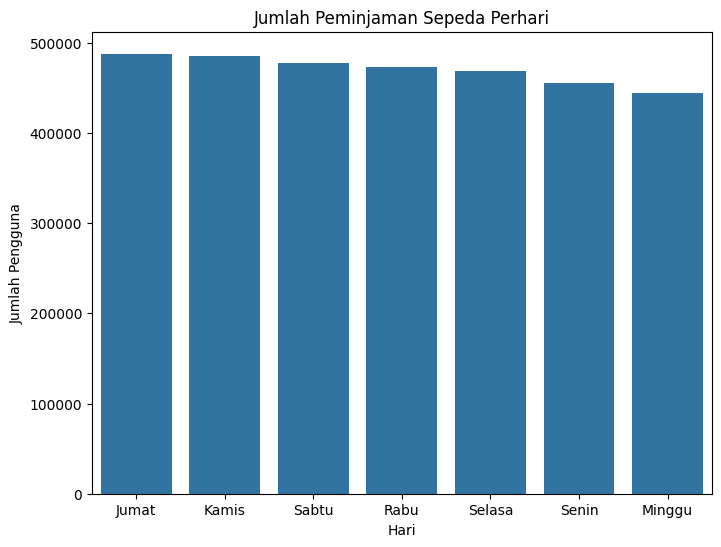

In [227]:
plt.figure(figsize=(8, 6))
sns.barplot(x='weekday', y='cnt', data=df_hari_sorted)
plt.title('Jumlah Peminjaman Sepeda Perhari')
plt.xlabel('Hari')
plt.ylabel('Jumlah Pengguna')
plt.show()

Menghitung jumlah pengguna berdarkan Jam//Hour berapa menyewa

In [228]:
df_hour = hour_df.groupby('hr')['cnt'].sum().reset_index()
print(df_hour)

    hr     cnt
0    0   39130
1    1   24164
2    2   16352
3    3    8174
4    4    4428
5    5   14261
6    6   55132
7    7  154171
8    8  261001
9    9  159438
10  10  126257
11  11  151320
12  12  184414
13  13  184919
14  14  175652
15  15  183149
16  16  227748
17  17  336860
18  18  309772
19  19  226789
20  20  164550
21  21  125445
22  22   95612
23  23   63941


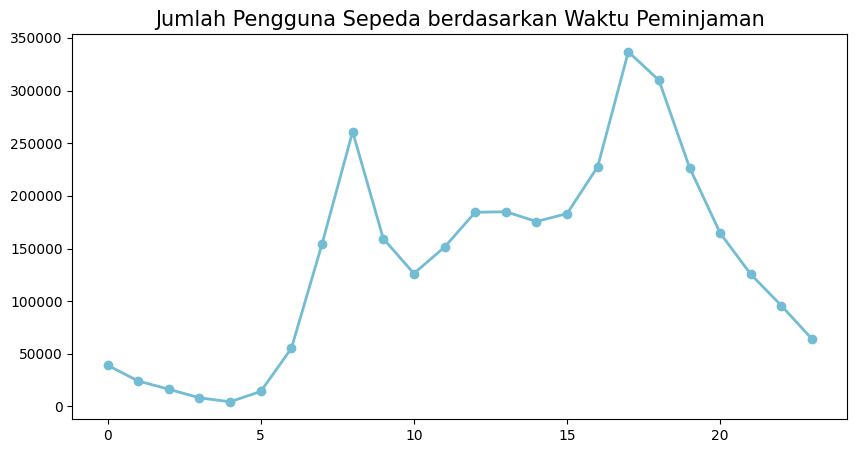

In [229]:
df_hour = hour_df.groupby('hr')['cnt'].sum().reset_index()
plt.figure(figsize=(10, 5)) 
plt.plot(df_hour["hr"], df_hour["cnt"], marker='o', linewidth=2, color="#72BCD4") 
plt.title("Jumlah Pengguna Sepeda berdasarkan Waktu Peminjaman", loc="center", fontsize=15) 
plt.xticks(fontsize=10) 
plt.yticks(fontsize=10) 
plt.show()

### Pertanyaan 2: Bagaimana pengaruh musim dan cuaca terhadap jumlah penyewaan sepeda?

Mengganti nama season/musim

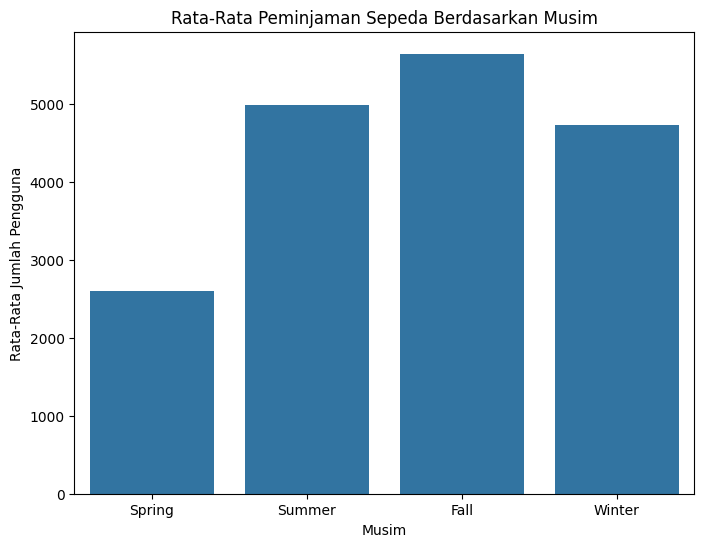

In [230]:
season_grouped = day_df.groupby('season')['cnt'].mean().reset_index()
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}

season_grouped['season'] = season_grouped['season'].map(season_mapping)


plt.figure(figsize=(8, 6))
sns.barplot(x='season', y='cnt', data=season_grouped)
plt.title('Rata-Rata Peminjaman Sepeda Berdasarkan Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-Rata Jumlah Pengguna')
plt.show()

Mengganti nama cuaca

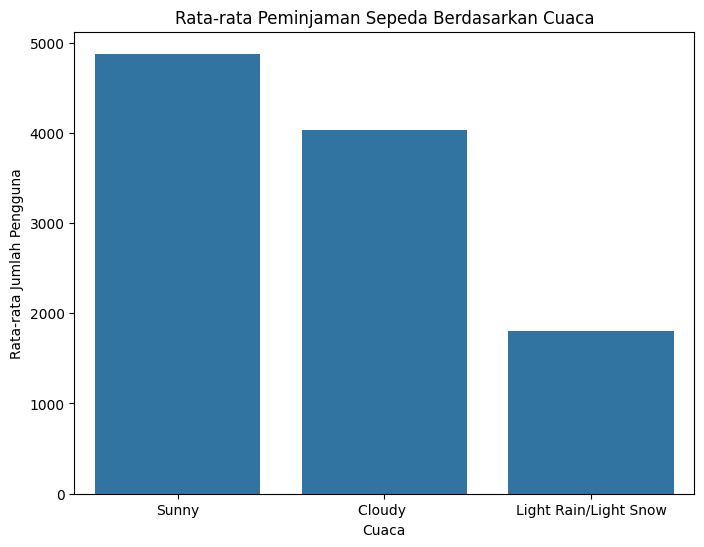

In [231]:
weather_grouped = day_df.groupby('weathersit')['cnt'].mean().reset_index()
weather_mapping = {1: 'Sunny', 2: 'Cloudy ', 3: 'Light Rain/Light Snow', 4: 'Extreme'}

weather_grouped['weathersit'] = weather_grouped['weathersit'].map(weather_mapping)


plt.figure(figsize=(8, 6))
sns.barplot(x='weathersit', y='cnt', data=weather_grouped)
plt.title('Rata-rata Peminjaman Sepeda Berdasarkan Cuaca')
plt.xlabel('Cuaca')
plt.ylabel('Rata-rata Jumlah Pengguna')
plt.show()

### Pertanyaan 3: Bagaimana perbandingan penyewaan sepeda pada hari kerja dan hari libur?

Menghitung perbandingan penyewaan sepeda pada hari kerja dan libur berdasarkan jumlah rata-rata serta membuat bar chartnya

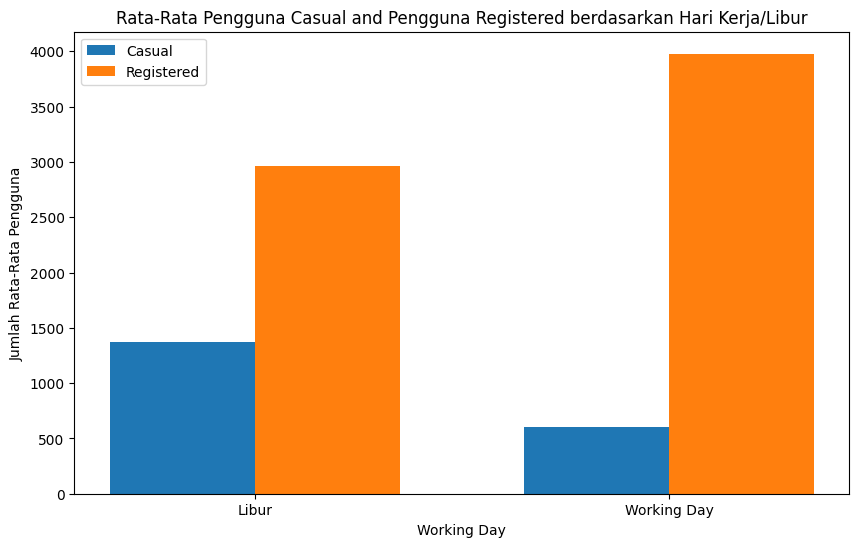

In [232]:
workingday_df = day_df.groupby('workingday')[['casual', 'registered']].mean().reset_index()
df_sort_workingday = workingday_df.sort_values(by=['casual', 'registered'], ascending=False)

workingday_labels = {0: 'Libur', 1: 'Working Day'}  # Memetakan label workingday dan hari libur
df_sort_workingday['workingday'] = df_sort_workingday['workingday'].map(workingday_labels)

plt.figure(figsize=(10, 6))
bar_width = 0.35

index = range(len(df_sort_workingday))

plt.bar(index, df_sort_workingday['casual'], bar_width, label='Casual')

plt.bar([i + bar_width for i in index], df_sort_workingday['registered'], bar_width, label='Registered')

plt.xlabel('Working Day')
plt.ylabel('Jumlah Rata-Rata Pengguna')
plt.title('Rata-Rata Pengguna Casual and Pengguna Registered berdasarkan Hari Kerja/Libur')
plt.xticks([i + bar_width / 2 for i in index], df_sort_workingday['workingday']) 
plt.legend()

plt.show()

Menghitung perbandingan penyewaan sepeda pada hari kerja dan libur berdasarkan penggua casual serta membuat pie chartnya

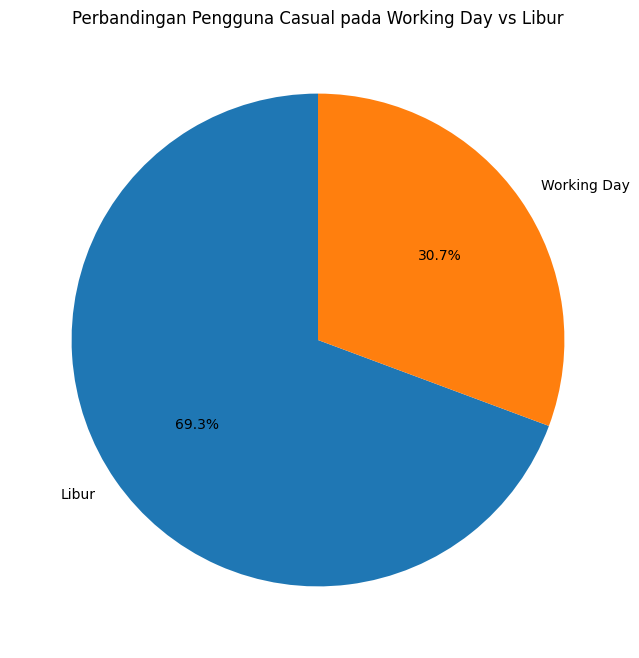

In [233]:
workingday_df = day_df.groupby('workingday')[['casual']].mean().reset_index()

# Memetakan 0 untuk Libur day dan 1 untuk Working day
workingday_labels = {0: 'Libur', 1: 'Working Day'}
workingday_df['workingday'] = workingday_df['workingday'].map(workingday_labels)

plt.figure(figsize=(8, 8))
plt.pie(workingday_df['casual'], labels=workingday_df['workingday'], autopct='%1.1f%%', startangle=90)

plt.title('Perbandingan Pengguna Casual pada Working Day vs Libur')

plt.show()

Menghitung perbandingan penyewaan sepeda pada hari kerja dan libur berdasarkan penggua registered serta membuat pie chartnya

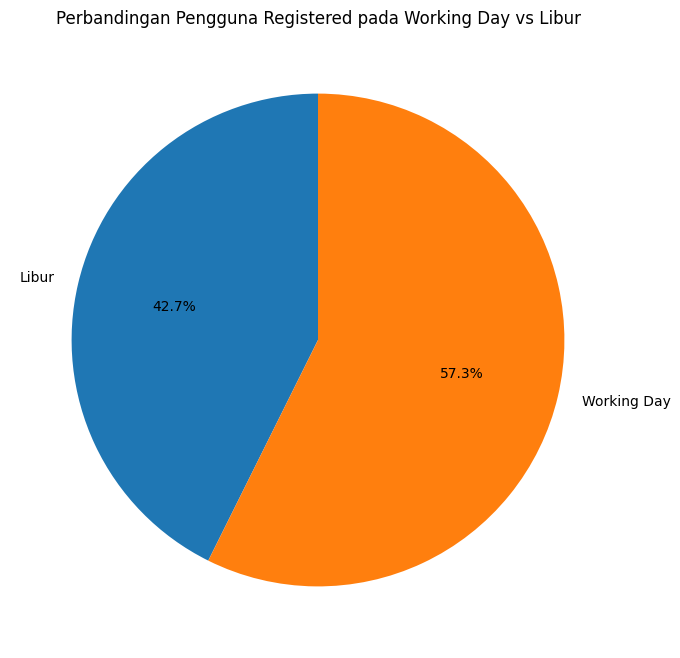

In [234]:
workingday_df = day_df.groupby('workingday')[['registered']].mean().reset_index()

# Memetakan 0 untuk Non-working day dan 1 untuk Working day
workingday_labels = {0: 'Libur', 1: 'Working Day'}
workingday_df['workingday'] = workingday_df['workingday'].map(workingday_labels)

plt.figure(figsize=(8, 8))
plt.pie(workingday_df['registered'], labels=workingday_df['workingday'], autopct='%1.1f%%', startangle=90)

plt.title('Perbandingan Pengguna Registered pada Working Day vs Libur')

plt.show()

**Insight:**
- Jumlah pengguna terbanyak ada pada hari jumat, tetapi perbandingan jumlah pengguna perhari tidak terlalu signifikan.
- Jam dengan peningkatan jumlah pengguna yang signifikan terjadi pada jam 07.00 menuju 08.00 dan jam 16.00 menuju 17.00. Pada kedua waktu tersebut adalah waktu berangkat dan pulang kerja.
- Berdasarkan musim pengguna atau penyewa sepeda terbanyak terjadi pada musim gugur. Sedangkan berdasarkan kondisi cuaca pengguna atau penyewa sepeda terbanyak terjadi pada cuaca cenderung cerah. Pada cuaca ekstrim tidak ada pengguna/penyewa sepeda
- Rata-rata jumlah penyewa sepeda untuk pengguna casual pada hari libur hampir dua kali lipat dibanding pada hari kerja.
Sedangkan, Rata-rata jumlah penyewaan sepeda untuk pengguna registered pada hari kerja lebih banyak dibanding pada hari libur.

## Analisis Lanjutan (Opsional)

## Conclusion

- Pengguna terbanyak ada pada hari jumat dan jam teramai ada pada jam 17.00. Pengguna terbanyak pada hari kerja dan jam pulang kerja.
- Musim dan Cuaca berpengaruh terhadap jumlah pengguna/penyewa sepeda.
- Rata-rata jumlah penyewa sepeda untuk pengguna casual pada hari libur hampir dua kali lipat dibanding pada hari kerja.
Sedangkan, Rata-rata jumlah penyewaan sepeda untuk pengguna registered pada hari kerja lebih banyak dibanding pada hari libur

In [235]:
day_df.to_csv("day_data.csv", index=False)

In [236]:
hour_df.to_csv("hour_data.csv", index=False)